<a href="https://colab.research.google.com/github/sadaffatimaee/DATA266_Lab1_Team16/blob/main/%20%20%20task2_sentiment/Sadaf_Fatima_Syeda/src/task2_sadaf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

SMOKE = False

CFG = dict(
    member      = "Sadaf_Fatima_Syeda",
    seed        = 266,
    n_train     = 100_000,     # random 100K from the 560K train set
    n_val       = 5_000,       # validation split taken from the 100K
    test        = "official",  # use the full 38K test set
    max_len     = 256,         # cap reviews at 256 tokens
    max_vocab   = 20_000,
    min_freq    = 2,
    batch_size  = 64,
    lemmatize   = True,
    slices      = dict(short_max_words=50, long_min_words=150),   # word counts for short / long reviews
    models = {
        "Baseline":            dict(embed_dim=128, lr=1e-3, epochs=3),
        "BiGRU_Attention":     dict(embed_dim=128, hidden_dim=64, lr=1e-3, epochs=3),
        "Transformer_Encoder": dict(embed_dim=128, n_head=4, n_layer=2, dropout=0.1, lr=5e-4, epochs=3),
    },
    n_bootstrap = 1000,
    ece_bins    = 15,
)
if SMOKE:
    CFG.update(n_train=3000, n_val=500, n_bootstrap=100)
    for m in CFG["models"].values(): m["epochs"] = 1
print(CFG)

{'member': 'Sadaf_Fatima_Syeda', 'seed': 266, 'n_train': 100000, 'n_val': 5000, 'test': 'official', 'max_len': 256, 'max_vocab': 20000, 'min_freq': 2, 'batch_size': 64, 'lemmatize': True, 'slices': {'short_max_words': 50, 'long_min_words': 150}, 'models': {'Baseline': {'embed_dim': 128, 'lr': 0.001, 'epochs': 3}, 'BiGRU_Attention': {'embed_dim': 128, 'hidden_dim': 64, 'lr': 0.001, 'epochs': 3}, 'Transformer_Encoder': {'embed_dim': 128, 'n_head': 4, 'n_layer': 2, 'dropout': 0.1, 'lr': 0.0005, 'epochs': 3}}, 'n_bootstrap': 1000, 'ece_bins': 15}


In [2]:
# 1. Setup folders, seed, log file and hardware info
import os, sys, re, json, time, math, random, platform, subprocess, datetime
import numpy as np, torch

OUT  = f"task2_sentiment/{CFG['member']}"
DIRS = {k: f"{OUT}/{k}" for k in ["src", "checkpoints", "outputs", "data_processed"]}
LOGD, MAND = "reproducibility/raw_logs", "reproducibility/manifests"
for d in list(DIRS.values()) + [LOGD, MAND]:
    os.makedirs(d, exist_ok=True)

def set_seed(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed(CFG["seed"])
device = 'cuda' if torch.cuda.is_available() else 'cpu'
DEVICE_NAME = torch.cuda.get_device_name(0) if device == 'cuda' else (platform.processor() or platform.machine())

RUN_ID   = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
LOG_PATH = f"{LOGD}/task2_sadaf_{RUN_ID}.log"
_logf = open(LOG_PATH, "a", buffering=1)
def log(msg=""):
    line = f"[{datetime.datetime.now().isoformat(timespec='seconds')}] {msg}"
    print(line); _logf.write(line + "\n")
def sh(cmd):
    try: return subprocess.run(cmd, shell=True, capture_output=True, text=True).stdout.strip()
    except Exception as e: return f"n/a ({e})"

log(f"RUN_ID {RUN_ID} | python {sys.version.split()[0]} | torch {torch.__version__} | device {device} ({DEVICE_NAME})")
log("nvidia-smi:\n" + (sh("nvidia-smi") or "n/a"))
log("CPU: " + (sh("lscpu | grep 'Model name'") or platform.processor()) + f" | {os.cpu_count()} cores")
log("CONFIG " + json.dumps(CFG))
json.dump(CFG, open(f"{DIRS['outputs']}/config.json", "w"), indent=2)

[2026-09-26T06:10:12] RUN_ID 20260926_061012 | python 3.13.15 | torch 2.11.0+cu128 | device cuda (Tesla T4)
[2026-09-26T06:10:12] nvidia-smi:
Sat Sep 26 06:10:12 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default 

In [3]:
# 2. Load Yelp Polarity dataset from Hugging Face
def load_yelp():
    from datasets import load_dataset
    ds = load_dataset("fancyzhx/yelp_polarity")
    return (list(ds["train"]["text"]), list(ds["train"]["label"]),
            list(ds["test"]["text"]),  list(ds["test"]["label"]))

all_train_texts, all_train_labels, test_texts, test_labels = load_yelp()
log(f"full train {len(all_train_texts):,} | official test {len(test_texts):,}")

rng = np.random.default_rng(CFG["seed"])
idx = rng.permutation(len(all_train_texts))[:CFG["n_train"]]
sub_texts  = [all_train_texts[i] for i in idx]
sub_labels = [int(all_train_labels[i]) for i in idx]
test_labels = [int(y) for y in test_labels]
if SMOKE:
    test_texts, test_labels = test_texts[:1000], test_labels[:1000]
log(f"my train subset {len(sub_texts):,} (seed {CFG['seed']}) | test {len(test_texts):,}")

README.md:   0%|          | 0.00/8.93k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  256MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 17.7MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/560000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/38000 [00:00<?, ? examples/s]

[2026-09-26T06:11:00] full train 560,000 | official test 38,000
[2026-09-26T06:11:00] my train subset 100,000 (seed 266) | test 38,000


[2026-09-26T06:11:11] EDA {"test": {"n": 38000, "class_counts": {"negative": 19000, "positive": 19000}, "positive_share": 0.5, "non_string": 0, "empty": 0, "literal_escape_sequences": 20219, "contains_url": 180, "non_ascii": 0, "duplicates": 0, "words_mean": 132.6, "words_median": 97, "words_p95": 367, "words_max": 1007, "share_over_256_words": 0.1221}, "train": {"n": 100000, "class_counts": {"negative": 50216, "positive": 49784}, "positive_share": 0.4978, "non_string": 0, "empty": 0, "literal_escape_sequences": 53498, "contains_url": 422, "non_ascii": 0, "duplicates": 0, "words_mean": 133.2, "words_median": 97, "words_p95": 373, "words_max": 1015, "share_over_256_words": 0.1223}}


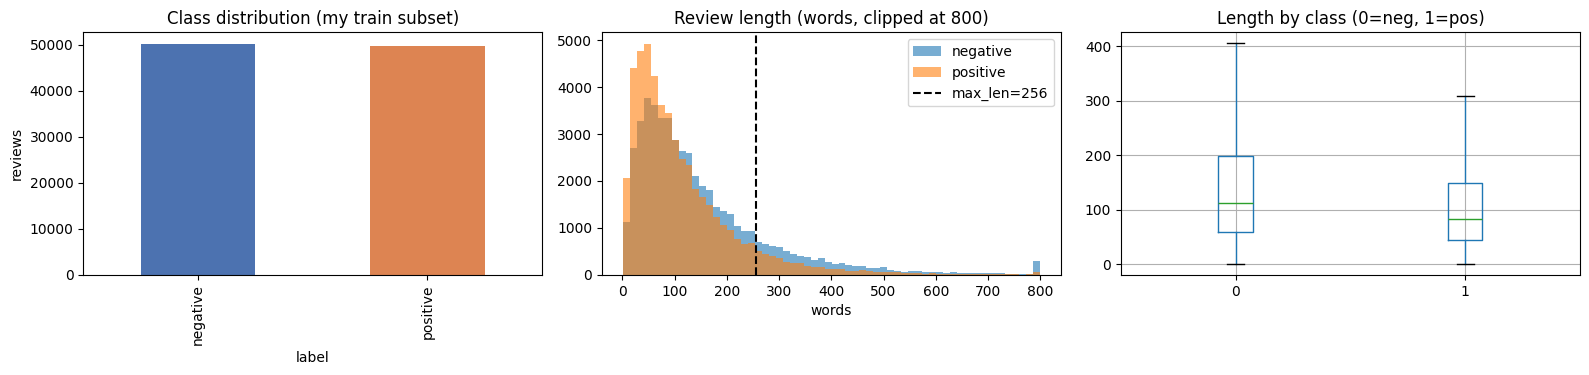

In [4]:
# 3. EDA: class distribution, review lengths and malformed entries
import pandas as pd, matplotlib.pyplot as plt

def eda_frame(texts, labels, split):
    return pd.DataFrame({"split": split, "label": labels,
                         "is_str": [isinstance(t, str) for t in texts],
                         "text": [t if isinstance(t, str) else "" for t in texts]})
eda = pd.concat([eda_frame(sub_texts, sub_labels, "train"), eda_frame(test_texts, test_labels, "test")],
                ignore_index=True)
eda["n_words"]       = eda.text.str.split().str.len().fillna(0).astype(int)
eda["is_empty"]      = eda.text.str.strip().eq("")
eda["literal_escape"] = eda.text.str.contains(r'\\n|\\"', regex=True)   # some reviews have \n as plain text
eda["has_url"]       = eda.text.str.contains(r"http\S+|www\.\S+", regex=True)
eda["non_ascii"]     = eda.text.map(lambda s: any(ord(c) > 127 for c in s))
eda["dup_in_split"]  = eda.duplicated(subset=["split", "text"])

summary = {}
for split, g in eda.groupby("split"):
    summary[split] = {
        "n": len(g),
        "class_counts": {("positive" if k == 1 else "negative"): int(v) for k, v in g.label.value_counts().sort_index().items()},
        "positive_share": round(g.label.mean(), 4),
        "non_string": int((~g.is_str).sum()), "empty": int(g.is_empty.sum()),
        "literal_escape_sequences": int(g.literal_escape.sum()), "contains_url": int(g.has_url.sum()),
        "non_ascii": int(g.non_ascii.sum()), "duplicates": int(g.dup_in_split.sum()),
        "words_mean": round(g.n_words.mean(), 1), "words_median": int(g.n_words.median()),
        "words_p95": int(g.n_words.quantile(.95)), "words_max": int(g.n_words.max()),
        "share_over_256_words": round((g.n_words > 256).mean(), 4),
    }
json.dump(summary, open(f"{DIRS['outputs']}/eda_summary.json", "w"), indent=2)
log("EDA " + json.dumps(summary))

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
tr = eda[eda.split == "train"]
tr.label.map({0: "negative", 1: "positive"}).value_counts().plot.bar(ax=ax[0], color=["#4C72B0", "#DD8452"])
ax[0].set_title("Class distribution (my train subset)"); ax[0].set_ylabel("reviews")
for lab, name in [(0, "negative"), (1, "positive")]:
    ax[1].hist(tr[tr.label == lab].n_words.clip(upper=800), bins=60, alpha=.6, label=name)
ax[1].axvline(CFG["max_len"], ls="--", c="k", label=f"max_len={CFG['max_len']}")
ax[1].set_title("Review length (words, clipped at 800)"); ax[1].set_xlabel("words"); ax[1].legend()
tr.boxplot(column="n_words", by="label", ax=ax[2], showfliers=False)
ax[2].set_title("Length by class (0=neg, 1=pos)"); ax[2].set_xlabel(""); plt.suptitle("")
plt.tight_layout(); plt.savefig(f"{DIRS['outputs']}/eda.png", dpi=150, bbox_inches="tight"); plt.show()

In [5]:
# 4. Text cleaning utility
# Lowercase, remove punctuation, remove stopwords (keeping negation words), lemmatize
from functools import lru_cache
NEGATIONS = {"not", "no", "nor", "never", "none", "nobody", "nothing", "neither", "nowhere", "without", "cannot"}
try:
    import nltk
    for pkg in ["stopwords", "wordnet", "omw-1.4"]:
        nltk.download(pkg, quiet=True)
    from nltk.corpus import stopwords
    from nltk.stem import WordNetLemmatizer
    STOP = set(stopwords.words("english"))
    _lem = WordNetLemmatizer(); _lem.lemmatize("tests")
    STOP_SOURCE, LEMMATIZER = "nltk", "wordnet"
except Exception as e:
    from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
    STOP, _lem, STOP_SOURCE, LEMMATIZER = set(ENGLISH_STOP_WORDS), None, "sklearn", "none"
    log(f"NLTK unavailable ({e}), using sklearn stopwords, no lemmatization")
STOP = {w for w in STOP if w not in NEGATIONS and not w.endswith("n't")}

@lru_cache(maxsize=None)
def lemma(w):
    return _lem.lemmatize(w) if (_lem is not None and CFG["lemmatize"]) else w

def clean_text(text):
    if not isinstance(text, str):                           # skip missing values
        return ""
    t = text.replace('\\n', ' ').replace('\\"', '"')        # fix the \n text in reviews
    t = t.lower()
    t = re.sub(r"http\S+|www\.\S+", " ", t)                 # remove links
    t = re.sub(r"n't\b", " not", t)                         # don't becomes do not
    t = re.sub(r"[^a-z0-9\s]", " ", t)                      # remove punctuation and special characters
    return re.sub(r"\s+", " ", t).strip()

def tokenize(text):
    return [lemma(w) for w in clean_text(text).split() if w not in STOP]

t0 = time.time()
tok_sub  = [tokenize(t) for t in sub_texts]
tok_test = [tokenize(t) for t in test_texts]
log(f"preprocessed {len(tok_sub)+len(tok_test):,} reviews in {time.time()-t0:.0f}s | stopwords={STOP_SOURCE} "
    f"({len(STOP)} words, negations kept) | lemmatizer={LEMMATIZER}")
log("example raw  : " + repr(sub_texts[0][:200]))
log("example clean: " + repr(" ".join(tok_sub[0][:40])))
empty_after = sum(len(t) == 0 for t in tok_sub) + sum(len(t) == 0 for t in tok_test)
log(f"reviews empty after cleaning: {empty_after} (mapped to a single <UNK>)")

[2026-09-26T06:11:34] preprocessed 138,000 reviews in 16s | stopwords=nltk (177 words, negations kept) | lemmatizer=wordnet
[2026-09-26T06:11:34] example raw  : 'Sorry, but I have to do this.\\n\\nI have had good sushi experiences so many times at this place, but one near-death event really helps to wipe those memories away.\\n\\nI got food poisoning from the sush'
[2026-09-26T06:11:34] example clean: 'sorry good sushi experience many time place one near death event really help wipe memory away got food poisoning sushi bar know sushi bar thing eaten day toast time finished roll stomach already starting feel weird contaminated stuff cause body'
[2026-09-26T06:11:34] reviews empty after cleaning: 6 (mapped to a single <UNK>)


In [6]:
# 5. Build vocabulary from scratch
from collections import Counter

val_n = CFG["n_val"]
tok_tr, y_tr   = tok_sub[val_n:], sub_labels[val_n:]
tok_val, y_val = tok_sub[:val_n], sub_labels[:val_n]
raw_val = sub_texts[:val_n]

counter = Counter(w for toks in tok_tr for w in toks)
vocab = {"<PAD>": 0, "<UNK>": 1}
for w, c in counter.most_common(CFG["max_vocab"] - 2):
    if c < CFG["min_freq"]: break
    vocab[w] = len(vocab)
log(f"vocab {len(vocab):,} (from {len(counter):,} unique train tokens, min_freq {CFG['min_freq']})")

L = CFG["max_len"]
def encode(toks):
    ids = [vocab.get(w, 1) for w in toks][:L] or [1]
    return ids + [0] * (L - len(ids)), min(len(ids), L)
def encode_all(tok_lists):
    enc = [encode(t) for t in tok_lists]
    return (np.array([e[0] for e in enc], dtype=np.uint16), np.array([e[1] for e in enc], dtype=np.int32))

X_tr, len_tr     = encode_all(tok_tr)
X_val, len_val   = encode_all(tok_val)
X_test, len_test = encode_all(tok_test)
y_tr, y_val, y_test = map(lambda a: np.array(a, dtype=np.int64), (y_tr, y_val, test_labels))
trunc_rate = float(np.mean([len(t) > L for t in tok_test]))
log(f"train {len(X_tr):,} | val {len(X_val):,} | test {len(X_test):,} | test reviews truncated at {L}: {trunc_rate:.2%}")

np.savez_compressed(f"{DIRS['data_processed']}/encoded.npz", X_tr=X_tr, len_tr=len_tr, y_tr=y_tr,
                    X_val=X_val, len_val=len_val, y_val=y_val, X_test=X_test, len_test=len_test, y_test=y_test,
                    train_subset_idx=idx)
json.dump(vocab, open(f"{DIRS['data_processed']}/vocab.json", "w"))
json.dump({"stopwords": STOP_SOURCE, "negations_kept": sorted(NEGATIONS), "lemmatizer": LEMMATIZER,
           "max_len": L, "vocab_size": len(vocab), "seed": CFG["seed"]},
          open(f"{DIRS['data_processed']}/preprocessing.json", "w"), indent=2)

[2026-09-26T06:11:35] vocab 20,000 (from 78,454 unique train tokens, min_freq 2)
[2026-09-26T06:11:39] train 95,000 | val 5,000 | test 38,000 | test reviews truncated at 256: 2.06%


In [7]:
# 6. Data slices for robustness checks
raw_words = np.array([len(t.split()) if isinstance(t, str) else 0 for t in test_texts])
neg_re = re.compile(r"\b(not|no|never|nothing|nobody|none|nor|cannot|without)\b|n't\b", re.I)
S = CFG["slices"]
slice_masks = {
    f"short (<= {S['short_max_words']} words)": raw_words <= S["short_max_words"],
    f"medium ({S['short_max_words']+1}-{S['long_min_words']-1})": (raw_words > S["short_max_words"]) & (raw_words < S["long_min_words"]),
    f"long (>= {S['long_min_words']} words)": raw_words >= S["long_min_words"],
    "contains negation": np.array([bool(neg_re.search(t)) if isinstance(t, str) else False for t in test_texts]),
    f"truncated (> {L} tokens)": np.array([len(t) > L for t in tok_test]),
}
log("slice sizes: " + json.dumps({k: int(v.sum()) for k, v in slice_masks.items()}))

[2026-09-26T06:11:42] slice sizes: {"short (<= 50 words)": 9362, "medium (51-149)": 16853, "long (>= 150 words)": 11785, "contains negation": 28514, "truncated (> 256 tokens)": 782}


In [8]:
# 7. Model architectures
import torch.nn as nn
from torch.nn import functional as F
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

class BaselineSentimentModel(nn.Module):
    """ Baseline: Learned Embedding + Max Pooling + Linear Classifier """
    def __init__(self, vocab_size, embed_dim=128, num_classes=2, **_):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.fc = nn.Linear(embed_dim, num_classes)
    def forward(self, x, lengths=None):
        emb = self.embedding(x)
        emb = emb.masked_fill((x == 0).unsqueeze(-1), float("-inf"))   # ignore padding in max pooling
        pooled, _ = emb.max(dim=1)
        return self.fc(pooled)

class AttentionPooling(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attention_weights = nn.Linear(hidden_dim, 1)
    def forward(self, h, pad_mask):
        scores = self.attention_weights(h).squeeze(-1).masked_fill(pad_mask, float("-inf"))
        w = torch.softmax(scores, dim=1).unsqueeze(-1)
        return (w * h).sum(dim=1)

class BiGRUAttentionModel(nn.Module):
    """ BiGRU with attention pooling """
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=64, num_classes=2, **_):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.bigru = nn.GRU(embed_dim, hidden_dim, num_layers=1, batch_first=True, bidirectional=True)
        self.attention_pool = AttentionPooling(hidden_dim * 2)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)
    def forward(self, x, lengths):
        emb = self.embedding(x)
        packed = pack_padded_sequence(emb, lengths.cpu(), batch_first=True, enforce_sorted=False)
        out, _ = self.bigru(packed)
        out, _ = pad_packed_sequence(out, batch_first=True, total_length=x.size(1))
        return self.fc(self.attention_pool(out, x == 0))

# Transformer encoder built from my Task 1 attention code (no causal mask here)
class EncHead(nn.Module):
    def __init__(self, n_embd, head_size, dropout):
        super().__init__()
        self.key   = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x, pad_mask):
        k, q, v = self.key(x), self.query(x), self.value(x)
        wei = q @ k.transpose(-2, -1) * (k.size(-1) ** -0.5)             # (B, T, T)
        wei = wei.masked_fill(pad_mask.unsqueeze(1), float("-inf"))     # mask padding tokens
        wei = self.dropout(F.softmax(wei, dim=-1))
        return wei @ v

class EncMultiHead(nn.Module):
    def __init__(self, n_embd, n_head, dropout):
        super().__init__()
        self.heads = nn.ModuleList([EncHead(n_embd, n_embd // n_head, dropout) for _ in range(n_head)])
        self.proj = nn.Linear(n_embd, n_embd); self.dropout = nn.Dropout(dropout)
    def forward(self, x, pad_mask):
        return self.dropout(self.proj(torch.cat([h(x, pad_mask) for h in self.heads], dim=-1)))

class EncBlock(nn.Module):
    def __init__(self, n_embd, n_head, dropout):
        super().__init__()
        self.sa = EncMultiHead(n_embd, n_head, dropout)
        self.ffwd = nn.Sequential(nn.Linear(n_embd, 4 * n_embd), nn.ReLU(),
                                  nn.Linear(4 * n_embd, n_embd), nn.Dropout(dropout))
        self.ln1, self.ln2 = nn.LayerNorm(n_embd), nn.LayerNorm(n_embd)
    def forward(self, x, pad_mask):
        x = x + self.sa(self.ln1(x), pad_mask)
        return x + self.ffwd(self.ln2(x))

class TransformerEncoderSentimentModel(nn.Module):
    """ Transformer encoder sentiment model """
    def __init__(self, vocab_size, embed_dim=128, n_head=4, n_layer=2, dropout=0.1, max_len=256, num_classes=2, **_):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.pos_embedding = nn.Embedding(max_len, embed_dim)
        self.blocks = nn.ModuleList([EncBlock(embed_dim, n_head, dropout) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(embed_dim); self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(embed_dim, num_classes)
    def forward(self, x, lengths=None):
        pad = x == 0
        h = self.drop(self.token_embedding(x) + self.pos_embedding(torch.arange(x.size(1), device=x.device)))
        for blk in self.blocks:
            h = blk(h, pad)
        h = self.ln_f(h)
        keep = (~pad).unsqueeze(-1).float()
        return self.fc((h * keep).sum(1) / keep.sum(1).clamp(min=1))

MODEL_CLASSES = {"Baseline": BaselineSentimentModel, "BiGRU_Attention": BiGRUAttentionModel,
                 "Transformer_Encoder": TransformerEncoderSentimentModel}

In [9]:
# 8. Training loop for all 3 models
# Save best checkpoint and test probabilities for downstream metrics computation
from torch.utils.data import TensorDataset, DataLoader

def loader(X, lens, y, shuffle):
    ds = TensorDataset(torch.from_numpy(X.astype(np.int64)), torch.from_numpy(lens.astype(np.int64)), torch.from_numpy(y))
    return DataLoader(ds, batch_size=CFG["batch_size"], shuffle=shuffle,
                      generator=torch.Generator().manual_seed(CFG["seed"]) if shuffle else None)
dl_tr, dl_val, dl_test = loader(X_tr, len_tr, y_tr, True), loader(X_val, len_val, y_val, False), loader(X_test, len_test, y_test, False)

@torch.no_grad()
def predict(model, dl):
    model.eval(); probs, loss_sum = [], 0.0
    for xb, lb, yb in dl:
        xb, lb, yb = xb.to(device), lb.to(device), yb.to(device)
        logits = model(xb, lb)
        loss_sum += F.cross_entropy(logits, yb, reduction="sum").item()
        probs.append(torch.softmax(logits, -1)[:, 1].cpu())
    p = torch.cat(probs).numpy()
    return p, loss_sum / len(dl.dataset)

RUNS = {}
for name, mcfg in CFG["models"].items():
    set_seed(CFG["seed"])
    model = MODEL_CLASSES[name](len(vocab), max_len=L, **mcfg).to(device)
    n_params = sum(p.numel() for p in model.parameters())
    opt = torch.optim.Adam(model.parameters(), lr=mcfg["lr"])
    if device == "cuda": torch.cuda.reset_peak_memory_stats(); torch.cuda.synchronize()
    log(f"=== {name} | params {n_params:,} | cfg {mcfg} | device {DEVICE_NAME}")
    hist, best_val, t_start = [], -1.0, time.time()
    for ep in range(1, mcfg["epochs"] + 1):
        model.train(); run_loss = 0.0
        for xb, lb, yb in dl_tr:
            xb, lb, yb = xb.to(device), lb.to(device), yb.to(device)
            opt.zero_grad(set_to_none=True)
            loss = F.cross_entropy(model(xb, lb), yb)
            loss.backward(); opt.step()
            run_loss += loss.item() * len(yb)
        p_val, val_loss = predict(model, dl_val)
        val_acc = float(((p_val >= .5).astype(int) == y_val).mean())
        hist.append(dict(epoch=ep, train_loss=run_loss / len(y_tr), val_loss=val_loss, val_acc=val_acc))
        log(f"{name} epoch {ep} | train loss {hist[-1]['train_loss']:.4f} | val loss {val_loss:.4f} | val acc {val_acc:.4f}")
        if val_acc > best_val:
            best_val = val_acc
            torch.save({"model_state_dict": model.state_dict(), "cfg": mcfg, "epoch": ep, "val_acc": val_acc,
                        "vocab_size": len(vocab), "max_len": L}, f"{DIRS['checkpoints']}/{name}.pt")
    if device == "cuda": torch.cuda.synchronize()
    train_time = time.time() - t_start
    peak_mb = torch.cuda.max_memory_allocated() / 1024**2 if device == "cuda" else float("nan")

    model.load_state_dict(torch.load(f"{DIRS['checkpoints']}/{name}.pt")["model_state_dict"])   # load best epoch
    t0 = time.time(); p_test, test_loss = predict(model, dl_test)
    if device == "cuda": torch.cuda.synchronize()
    infer_eps = len(y_test) / (time.time() - t0)
    np.save(f"{DIRS['outputs']}/{name}_test_probs.npy", p_test)

    RUNS[name] = dict(probs=p_test, params=n_params, train_time=train_time, peak_mb=peak_mb,
                      train_eps=len(y_tr) * mcfg["epochs"] / train_time, infer_eps=infer_eps,
                      history=hist, best_epoch=max(hist, key=lambda h: h["val_acc"])["epoch"], test_loss=test_loss)
    log(f"{name} done | {train_time:.1f}s | {RUNS[name]['train_eps']:.0f} train ex/s | {infer_eps:.0f} infer ex/s | "
        f"peak {peak_mb:.0f} MB | best epoch {RUNS[name]['best_epoch']}")
    del model, opt
    if device == "cuda": torch.cuda.empty_cache()

pd.DataFrame([dict(model=n, **h) for n, r in RUNS.items() for h in r["history"]]).to_csv(f"{DIRS['outputs']}/training_history.csv", index=False)

[2026-09-26T06:11:48] === Baseline | params 2,560,258 | cfg {'embed_dim': 128, 'lr': 0.001, 'epochs': 3} | device Tesla T4
[2026-09-26T06:11:53] Baseline epoch 1 | train loss 0.4721 | val loss 0.3237 | val acc 0.8612
[2026-09-26T06:11:58] Baseline epoch 2 | train loss 0.2721 | val loss 0.2497 | val acc 0.8994
[2026-09-26T06:12:03] Baseline epoch 3 | train loss 0.2180 | val loss 0.2257 | val acc 0.9078
[2026-09-26T06:12:04] Baseline done | 14.9s | 19091 train ex/s | 35314 infer ex/s | peak 74 MB | best epoch 3
[2026-09-26T06:12:04] === BiGRU_Attention | params 2,634,883 | cfg {'embed_dim': 128, 'hidden_dim': 64, 'lr': 0.001, 'epochs': 3} | device Tesla T4
[2026-09-26T06:12:52] BiGRU_Attention epoch 1 | train loss 0.2439 | val loss 0.1765 | val acc 0.9302
[2026-09-26T06:13:39] BiGRU_Attention epoch 2 | train loss 0.1400 | val loss 0.1616 | val acc 0.9344
[2026-09-26T06:14:23] BiGRU_Attention epoch 3 | train loss 0.0964 | val loss 0.1718 | val acc 0.9364
[2026-09-26T06:14:29] BiGRU_Attent

In [10]:
# 9. Evaluate each model and collect metrics
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support, confusion_matrix, roc_auc_score,
                             average_precision_score, matthews_corrcoef, brier_score_loss, roc_curve, precision_recall_curve)
from statsmodels.stats.contingency_tables import mcnemar

def ece_score(y, p, n_bins):
    """ Compute Expected Calibration Error (ECE) """
    pred = (p >= .5).astype(int); conf = np.maximum(p, 1 - p); correct = (pred == y).astype(float)
    edges = np.linspace(.5, 1, n_bins + 1); ece = 0.0
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (conf > lo) & (conf <= hi) if lo > .5 else (conf >= lo) & (conf <= hi)
        if m.any(): ece += m.mean() * abs(correct[m].mean() - conf[m].mean())
    return ece

def macro_f1(y, pr): return precision_recall_fscore_support(y, pr, average="macro", zero_division=0)[2]
def bootstrap_ci(y, pr, fn, B, seed):
    r = np.random.default_rng(seed); n = len(y)
    s = [fn(y[i], pr[i]) for i in (r.integers(0, n, n) for _ in range(B))]
    return np.percentile(s, [2.5, 97.5])

y = y_test; rows, slice_rows, preds = [], [], {}
for name, r in RUNS.items():
    p = r["probs"]; pr = (p >= .5).astype(int); preds[name] = pr
    row = {"Model": name, "Device": DEVICE_NAME, "Best_Epoch": r["best_epoch"], "Accuracy": accuracy_score(y, pr)}
    for avg in ["macro", "micro", "weighted"]:
        P, R, F1, _ = precision_recall_fscore_support(y, pr, average=avg, zero_division=0)
        row.update({f"Precision_{avg}": P, f"Recall_{avg}": R, f"F1_{avg}": F1})
    tn, fp, fn, tp = confusion_matrix(y, pr, labels=[0, 1]).ravel()
    row.update(dict(CM_TN=tn, CM_FP=fp, CM_FN=fn, CM_TP=tp,
                    ROC_AUC=roc_auc_score(y, p), PR_AUC=average_precision_score(y, p),
                    MCC=matthews_corrcoef(y, pr), Brier=brier_score_loss(y, p), ECE=ece_score(y, p, CFG["ece_bins"])))
    for key, fn_ in [("Accuracy", accuracy_score), ("F1_macro", macro_f1), ("MCC", matthews_corrcoef)]:
        lo, hi = bootstrap_ci(y, pr, fn_, CFG["n_bootstrap"], CFG["seed"])
        row[f"{key}_CI95_low"], row[f"{key}_CI95_high"] = lo, hi
    if name == "Baseline":
        row.update(McNemar_b=np.nan, McNemar_c=np.nan, McNemar_stat=np.nan, McNemar_p=np.nan)
    else:
        bc, ec = preds["Baseline"] == y, pr == y
        table = [[int((bc & ec).sum()), int((bc & ~ec).sum())], [int((~bc & ec).sum()), int((~bc & ~ec).sum())]]
        res = mcnemar(table, exact=min(table[0][1], table[1][0]) < 25, correction=True)
        row.update(McNemar_b=table[0][1], McNemar_c=table[1][0], McNemar_stat=res.statistic, McNemar_p=res.pvalue)
    row.update(Params=r["params"], Train_Time_s=r["train_time"], Train_Examples_per_s=r["train_eps"],
               Inference_Examples_per_s=r["infer_eps"], Peak_Memory_MB=r["peak_mb"])
    rows.append(row)
    for sname, m in slice_masks.items():
        if m.sum() == 0: continue
        slice_rows.append({"Model": name, "Slice": sname, "N": int(m.sum()),
                           "Macro_F1": macro_f1(y[m], pr[m]), "Error_Rate": float((pr[m] != y[m]).mean())})

metrics = pd.DataFrame(rows); slices_df = pd.DataFrame(slice_rows)
metrics.to_csv(f"{OUT}/metrics_report.csv", index=False)
slices_df.to_csv(f"{DIRS['outputs']}/slice_metrics.csv", index=False)
pd.set_option("display.max_columns", None); display(metrics.set_index("Model").T)
display(slices_df.pivot(index="Slice", columns="Model", values=["Macro_F1", "Error_Rate"]).round(4))
log("METRICS " + metrics.to_json(orient="records"))
log("SLICES " + slices_df.to_json(orient="records"))

Model,Baseline,BiGRU_Attention,Transformer_Encoder
Device,Tesla T4,Tesla T4,Tesla T4
Best_Epoch,3,3,3
Accuracy,0.904,0.934,0.921632
Precision_macro,0.904001,0.934524,0.922144
Recall_macro,0.904,0.934,0.921632
F1_macro,0.904,0.93398,0.921608
Precision_micro,0.904,0.934,0.921632
Recall_micro,0.904,0.934,0.921632
F1_micro,0.904,0.934,0.921632
Precision_weighted,0.904001,0.934524,0.922144


Macro_F1                                      \
Model                    Baseline BiGRU_Attention Transformer_Encoder   
Slice                                                                   
contains negation          0.8956          0.9297              0.9140   
long (>= 150 words)        0.8973          0.9271              0.9170   
medium (51-149)            0.9059          0.9369              0.9233   
short (<= 50 words)        0.9002          0.9320              0.9184   
truncated (> 256 tokens)   0.8557          0.8806              0.8996   

                         Error_Rate                                      
Model                      Baseline BiGRU_Attention Transformer_Encoder  
Slice                                                                    
contains negation            0.1012          0.0686              0.0828  
long (>= 150 words)          0.0989          0.0709              0.0800  
medium (51-149)              0.0940          0.0630              0.0767  
short (<= 50 words)          0.0958          0.0652              0.0793  
truncated (> 256 tokens)     0.1176          0.1023              0.0818

[2026-09-26T06:18:19] METRICS [{"Model":"Baseline","Device":"Tesla T4","Best_Epoch":3,"Accuracy":0.904,"Precision_macro":0.9040006446,"Recall_macro":0.904,"F1_macro":0.9039999617,"Precision_micro":0.904,"Recall_micro":0.904,"F1_micro":0.904,"Precision_weighted":0.9040006446,"Recall_weighted":0.904,"F1_weighted":0.9039999617,"CM_TN":17164,"CM_FP":1836,"CM_FN":1812,"CM_TP":17188,"ROC_AUC":0.968008723,"PR_AUC":0.9692920578,"MCC":0.8080006446,"Brier":0.069310296,"ECE":0.004081171,"Accuracy_CI95_low":0.9010789474,"Accuracy_CI95_high":0.9066322368,"F1_macro_CI95_low":0.9010788776,"F1_macro_CI95_high":0.9066290498,"MCC_CI95_low":0.8021592596,"MCC_CI95_high":0.8132633748,"McNemar_b":null,"McNemar_c":null,"McNemar_stat":null,"McNemar_p":null,"Params":2560258,"Train_Time_s":14.928150177,"Train_Examples_per_s":19091.447809727,"Inference_Examples_per_s":35313.8654238921,"Peak_Memory_MB":74.4775390625},{"Model":"BiGRU_Attention","Device":"Tesla T4","Best_Epoch":3,"Accuracy":0.934,"Precision_macro":

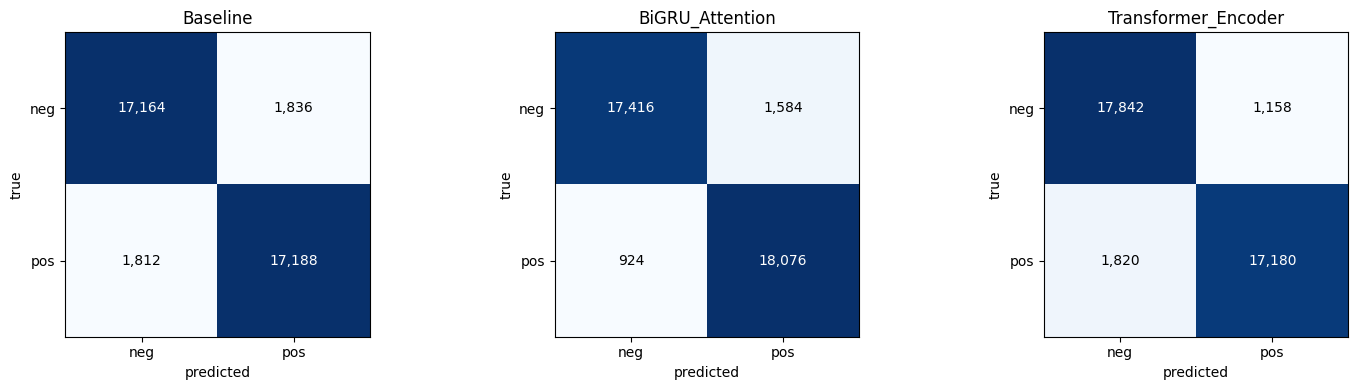

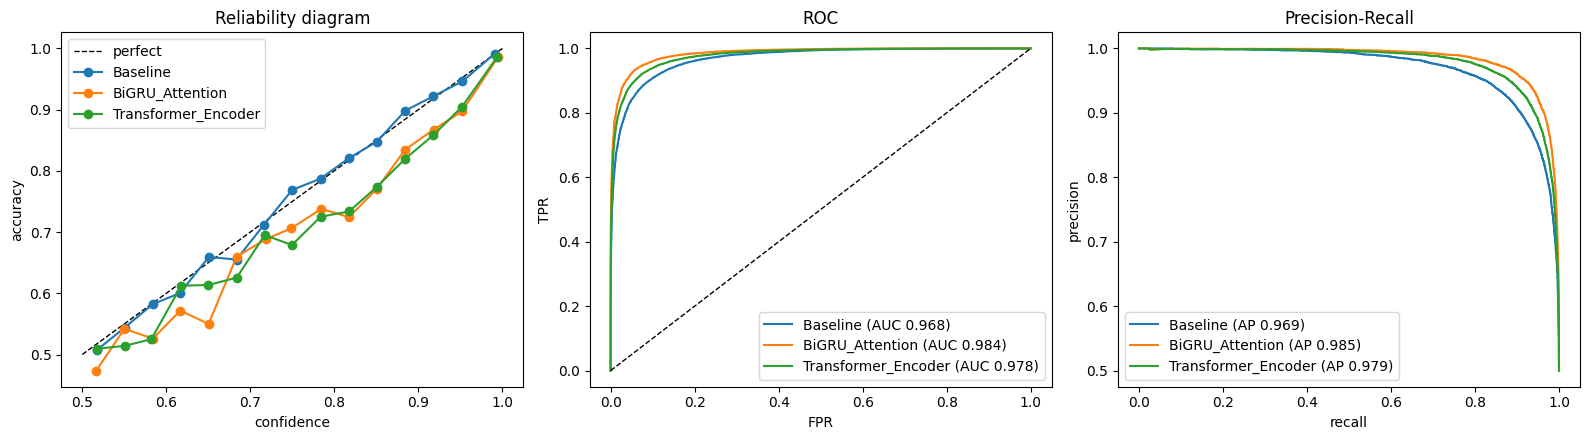

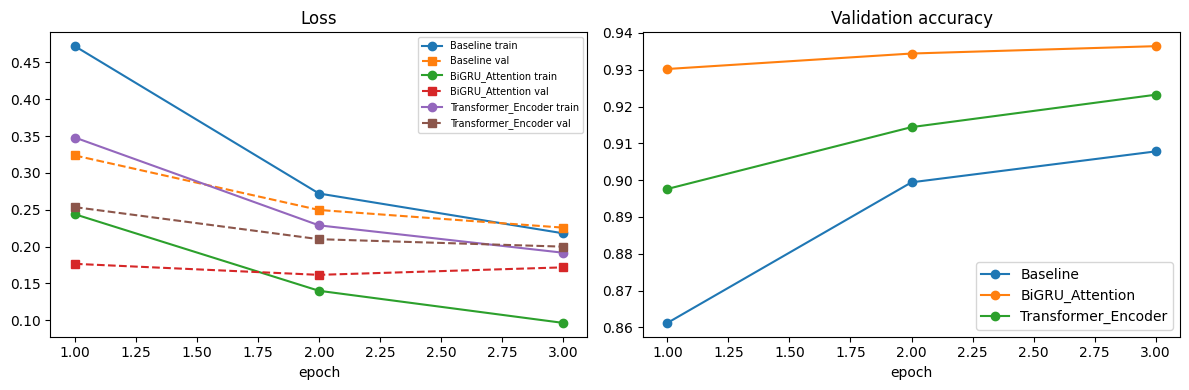

In [11]:
# 10. Confusion matrices, calibration, ROC / PR and training curves
names = list(RUNS)
fig, ax = plt.subplots(1, len(names), figsize=(5 * len(names), 4))
for a, n in zip(np.atleast_1d(ax), names):
    cm = confusion_matrix(y, preds[n], labels=[0, 1])
    a.imshow(cm, cmap="Blues")
    for i in range(2):
        for j in range(2):
            a.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", color="white" if cm[i, j] > cm.max() / 2 else "black")
    a.set_xticks([0, 1], ["neg", "pos"]); a.set_yticks([0, 1], ["neg", "pos"])
    a.set_xlabel("predicted"); a.set_ylabel("true"); a.set_title(n)
plt.tight_layout(); plt.savefig(f"{DIRS['outputs']}/confusion_matrices.png", dpi=150, bbox_inches="tight"); plt.show()

fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
ax[0].plot([.5, 1], [.5, 1], "k--", lw=1, label="perfect")
for n in names:
    p = RUNS[n]["probs"]; pr = preds[n]; conf = np.maximum(p, 1 - p); corr = (pr == y)
    edges = np.linspace(.5, 1, CFG["ece_bins"] + 1); xs, ys = [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (conf >= lo) & (conf <= hi)
        if m.any(): xs.append(conf[m].mean()); ys.append(corr[m].mean())
    ax[0].plot(xs, ys, marker="o", label=n)
    fpr, tpr, _ = roc_curve(y, p); ax[1].plot(fpr, tpr, label=f"{n} (AUC {roc_auc_score(y, p):.3f})")
    prc, rec, _ = precision_recall_curve(y, p); ax[2].plot(rec, prc, label=f"{n} (AP {average_precision_score(y, p):.3f})")
ax[0].set(title="Reliability diagram", xlabel="confidence", ylabel="accuracy"); ax[0].legend()
ax[1].plot([0, 1], [0, 1], "k--", lw=1); ax[1].set(title="ROC", xlabel="FPR", ylabel="TPR"); ax[1].legend()
ax[2].set(title="Precision-Recall", xlabel="recall", ylabel="precision"); ax[2].legend()
plt.tight_layout(); plt.savefig(f"{DIRS['outputs']}/calibration_roc_pr.png", dpi=150, bbox_inches="tight"); plt.show()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for n in names:
    h = pd.DataFrame(RUNS[n]["history"])
    ax[0].plot(h.epoch, h.train_loss, marker="o", label=f"{n} train"); ax[0].plot(h.epoch, h.val_loss, marker="s", ls="--", label=f"{n} val")
    ax[1].plot(h.epoch, h.val_acc, marker="o", label=n)
ax[0].set(title="Loss", xlabel="epoch"); ax[0].legend(fontsize=7); ax[1].set(title="Validation accuracy", xlabel="epoch"); ax[1].legend()
plt.tight_layout(); plt.savefig(f"{DIRS['outputs']}/training_curves.png", dpi=150, bbox_inches="tight"); plt.show()

In [12]:
# 11. Error review: 5 confident false positives, 5 confident false negatives,
# 5 near-threshold errors and 5 slice-specific errors
REVIEW_MODEL = max(RUNS, key=lambda n: metrics.set_index("Model").loc[n, "F1_macro"])
p, pr = RUNS[REVIEW_MODEL]["probs"], preds[REVIEW_MODEL]
wrong = np.where(pr != y)[0]
fp = [i for i in wrong[np.argsort(-p[wrong])] if y[i] == 0][:5]
fn = [i for i in wrong[np.argsort(p[wrong])] if y[i] == 1][:5]
used = set(fp) | set(fn)
near = [i for i in wrong[np.argsort(np.abs(p[wrong] - .5))] if i not in used][:5]; used |= set(near)
worst_slice = slices_df[slices_df.Model == REVIEW_MODEL].sort_values("Error_Rate", ascending=False).iloc[0].Slice
sl = [i for i in wrong[np.argsort(-np.maximum(p[wrong], 1 - p[wrong]))] if slice_masks[worst_slice][i] and i not in used][:5]

def slices_of(i): return "; ".join(k for k, m in slice_masks.items() if m[i])
rev = []
for cat, ids in [("confident_false_positive", fp), ("confident_false_negative", fn),
                 ("near_threshold", near), (f"slice: {worst_slice}", sl)]:
    for i in ids:
        rev.append(dict(category=cat, test_index=int(i), true=int(y[i]), pred=int(pr[i]), p_positive=round(float(p[i]), 4),
                        slices=slices_of(i), text=test_texts[i].replace('\\n', ' '), error_type="", proposed_fix=""))
rev = pd.DataFrame(rev)
rev.to_csv(f"{DIRS['outputs']}/error_review_{REVIEW_MODEL}.csv", index=False)
log(f"error review sheet: {REVIEW_MODEL}, worst slice = {worst_slice}, {len(rev)} rows")
for _, r in rev.iterrows():
    print(f"[{r.category}] idx {r.test_index} | true {r.true} pred {r.pred} p={r.p_positive} | {r.text[:160]}")

[2026-09-26T06:18:22] error review sheet: BiGRU_Attention, worst slice = truncated (> 256 tokens), 20 rows
[confident_false_positive] idx 29330 | true 0 pred 1 p=1.0 | Wow love the place and everything is very clean and new!  Great place to come and relax worth a try!  Cheers,  Eric Van Nguyen Visited April 2012
[confident_false_positive] idx 27375 | true 0 pred 1 p=0.9998 | We had dinner here for four. Had an artichoke appetizer with pita chips, club sandwich and shared a huge sundae for dessert. The service was awesome; space impr
[confident_false_positive] idx 18122 | true 0 pred 1 p=0.9998 | 20 years for me and sad to see them go.  Sadder still to see a great traditional Japanese sushi restaurant end, and not carry on the tradition.  We would go her
[confident_false_positive] idx 1912 | true 0 pred 1 p=0.9996 | The food is a tad better than okay. The service is somewhat mixed, it depends who you get for the evening. Some are more motivated than others. The manager, Sum
[confident_f

In [13]:
# 12. Save manifest
manifest = {
    "run_id": RUN_ID, "member": CFG["member"], "task": "task2_sentiment",
    "timestamp": datetime.datetime.now().isoformat(timespec="seconds"),
    "python": sys.version, "torch": torch.__version__, "cuda": torch.version.cuda,
    "device": device, "device_name": DEVICE_NAME, "cpu": sh("lscpu | grep 'Model name'") or platform.processor(),
    "config": CFG, "dataset": "fancyzhx/yelp_polarity (official train/test)", "raw_log": LOG_PATH,
    "preprocessing": {"stopwords": STOP_SOURCE, "lemmatizer": LEMMATIZER, "negations_kept": sorted(NEGATIONS)},
    "checkpoint_to_result": {f"{DIRS['checkpoints']}/{n}.pt":
        f"{OUT}/metrics_report.csv row '{n}' (best epoch {RUNS[n]['best_epoch']}), probs {DIRS['outputs']}/{n}_test_probs.npy"
        for n in RUNS},
    "pip_freeze": sh(f"{sys.executable} -m pip freeze").splitlines(),
}
MAN_PATH = f"{MAND}/task2_sadaf_{RUN_ID}.json"
json.dump(manifest, open(MAN_PATH, "w"), indent=2, default=str)
sh(f"{sys.executable} -m pip freeze > {MAND}/task2_sadaf_requirements_{RUN_ID}.txt")
log(f"manifest -> {MAN_PATH}")
log("files: " + json.dumps({d: sorted(os.listdir(p)) for d, p in DIRS.items()}))
_logf.flush()

[2026-09-26T06:18:26] manifest -> reproducibility/manifests/task2_sadaf_20260926_061012.json
[2026-09-26T06:18:26] files: {"src": [], "checkpoints": ["Baseline.pt", "BiGRU_Attention.pt", "Transformer_Encoder.pt"], "outputs": ["Baseline_test_probs.npy", "BiGRU_Attention_test_probs.npy", "Transformer_Encoder_test_probs.npy", "calibration_roc_pr.png", "config.json", "confusion_matrices.png", "eda.png", "eda_summary.json", "error_review_BiGRU_Attention.csv", "slice_metrics.csv", "training_curves.png", "training_history.csv"], "data_processed": ["encoded.npz", "preprocessing.json", "vocab.json"]}


In [14]:
# 13. Zip the dataset and upload it to Google Drive (datasets can't be pushed to GitHub)
import shutil, zipfile
os.makedirs("task2_data", exist_ok=True)
pd.DataFrame({"text": sub_texts, "label": sub_labels, "orig_train_index": idx}).to_csv("task2_data/yelp_train_subset_100k.csv", index=False)
pd.DataFrame({"text": test_texts, "label": test_labels}).to_csv("task2_data/yelp_test_official.csv", index=False)
shutil.copy(f"{DIRS['data_processed']}/encoded.npz", "task2_data/encoded.npz")
shutil.copy(f"{DIRS['data_processed']}/vocab.json", "task2_data/vocab.json")
zip_name = f"task2_sadaf_yelp_data_{RUN_ID}.zip"
shutil.make_archive(zip_name[:-4], "zip", root_dir=".", base_dir="task2_data")
log(f"dataset zip: {zip_name} ({os.path.getsize(zip_name)/1e6:.1f} MB)")

try:
    from google.colab import drive
    drive.mount('/content/drive')
    ddir = "/content/drive/MyDrive/DATA266_Lab1_Data"
    os.makedirs(ddir, exist_ok=True)
    shutil.copy(zip_name, f"{ddir}/{zip_name}")
    shutil.copytree(DIRS["checkpoints"], f"/content/drive/MyDrive/DATA266_Lab1_Checkpoints/Task2_Sadaf/{RUN_ID}", dirs_exist_ok=True)
    log(f"uploaded to Drive: {ddir}/{zip_name}")
    print("\nNow open Google Drive -> DATA266_Lab1_Data -> right click the zip -> Share -> Anyone with the link (Viewer) -> Copy link")
except Exception as e:
    print("Drive upload skipped:", e)

with open(f"{DIRS['data_processed']}/DATA_LINK.md", "w") as f:
    f.write(f"# Task 2 data (Sadaf)\n\nDataset zip on Google Drive: `MyDrive/DATA266_Lab1_Data/{zip_name}`\n\n"
            "Link: PASTE_DRIVE_LINK_HERE\n\n"
            "Contains: my 100K Yelp train subset (seed 266), the official 38K test set, encoded tensors and vocab.\n")

[2026-09-26T06:18:37] dataset zip: task2_sadaf_yelp_data_20260926_061012.zip (56.7 MB)
Mounted at /content/drive
[2026-09-26T06:19:01] uploaded to Drive: /content/drive/MyDrive/DATA266_Lab1_Data/task2_sadaf_yelp_data_20260926_061012.zip

Now open Google Drive -> DATA266_Lab1_Data -> right click the zip -> Share -> Anyone with the link (Viewer) -> Copy link


In [15]:
# 14. Push to GitHub
REPO = "sadaffatimaee/DATA266_Lab1_Team16"
try:
    from google.colab import userdata
    token = userdata.get("GH_TOKEN")
except Exception:
    token = None

if not token:
    print("No GH_TOKEN found, skipping push.")
else:
    import shutil
    base, repo = os.getcwd(), "/content/repo"
    if os.path.exists(repo): shutil.rmtree(repo)
    subprocess.run(["git", "clone", "-q", f"https://{token}@github.com/{REPO}.git", repo], check=True)
    git = lambda *a: subprocess.run(["git", "-C", repo, *a], capture_output=True, text=True)
    me = f"{repo}/{OUT}"; os.makedirs(me, exist_ok=True)
    for sub in ["checkpoints", "outputs"]:
        shutil.copytree(f"{base}/{DIRS[sub]}", f"{me}/{sub}", dirs_exist_ok=True)
    # Only small files from data_processed go to GitHub, the encoded data goes to Drive
    os.makedirs(f"{me}/data_processed", exist_ok=True)
    for f in ["vocab.json", "preprocessing.json", "DATA_LINK.md"]:
        if os.path.exists(f"{base}/{DIRS['data_processed']}/{f}"):
            shutil.copy(f"{base}/{DIRS['data_processed']}/{f}", f"{me}/data_processed/{f}")
    shutil.copy(f"{base}/{OUT}/metrics_report.csv", f"{me}/metrics_report.csv")
    for d in [LOGD, MAND]:
        for f in os.listdir(f"{base}/{d}"):
            if f.startswith("task2_"):
                os.makedirs(f"{repo}/{d}", exist_ok=True); shutil.copy(f"{base}/{d}/{f}", f"{repo}/{d}/{f}")
    big = [f for f in sh(f"find {me} -type f -size +95M").splitlines() if f]
    if big: print("WARNING >95 MB, not pushed:", big); [os.remove(f) for f in big]
    git("config", "user.name", "Sadaf Fatima Syeda"); git("config", "user.email", "sadaffatima.syeda@sjsu.edu")
    git("add", "-A", OUT, LOGD, MAND)
    print(git("commit", "-m", f"Task 2 (Sadaf): run {RUN_ID}").stdout)
    r = git("push"); print(r.stdout, r.stderr.replace(token, "***"))

[main 1a4bcf0] Task 2 (Sadaf): run 20260926_061012
 22 files changed, 1699 insertions(+), 4 deletions(-)
 create mode 100644 reproducibility/manifests/task2_sadaf_20260926_061012.json
 create mode 100644 reproducibility/manifests/task2_sadaf_requirements_20260926_061012.txt
 create mode 100644 reproducibility/raw_logs/task2_sadaf_20260926_061012.log
 create mode 100644 task2_sentiment/Sadaf_Fatima_Syeda/checkpoints/Baseline.pt
 create mode 100644 task2_sentiment/Sadaf_Fatima_Syeda/checkpoints/BiGRU_Attention.pt
 create mode 100644 task2_sentiment/Sadaf_Fatima_Syeda/checkpoints/Transformer_Encoder.pt
 create mode 100644 task2_sentiment/Sadaf_Fatima_Syeda/data_processed/DATA_LINK.md
 create mode 100644 task2_sentiment/Sadaf_Fatima_Syeda/data_processed/preprocessing.json
 create mode 100644 task2_sentiment/Sadaf_Fatima_Syeda/data_processed/vocab.json
 create mode 100644 task2_sentiment/Sadaf_Fatima_Syeda/outputs/Baseline_test_probs.npy
 create mode 100644 task2_sentiment/Sadaf_Fatima_Syed